In [1]:
pip install pytrends matplotlib pandas seaborn plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 2.7 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.9 MB 2.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 2.6 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.9 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.9 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.9 MB 1.2 MB/s eta 0:00:06
   ---------- -------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Objective of that project

#### Write a Python code to search for multiple keywords by changing a single variable.

#### 1. Identify the top 15 countries where the keywords are searched the most and create a visual representation.

#### 2. Plot a world map (choropleth) showing the countries with the highest search interest for the keywords.

#### 3. Extract the time-wise search interest of the keywords to analyze trends over different years.

#### 4. Compare related keywords and visualize their trends on a graph.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from pytrends.request import TrendReq

# Setup pytrend library and keyword define

In [34]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=360)
keyword = "cloud computing"


# Request Data 

In [35]:
pytrends.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')

# Country wise interest

In [36]:
region_data = pytrends.interest_by_region()

region_data = region_data.sort_values(by=keyword, ascending=False).head(10)


C:\Users\SARS\AppData\Local\Temp\ipykernel_1128\674309116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_data[keyword], y=region_data.index, palette="Blues_d")


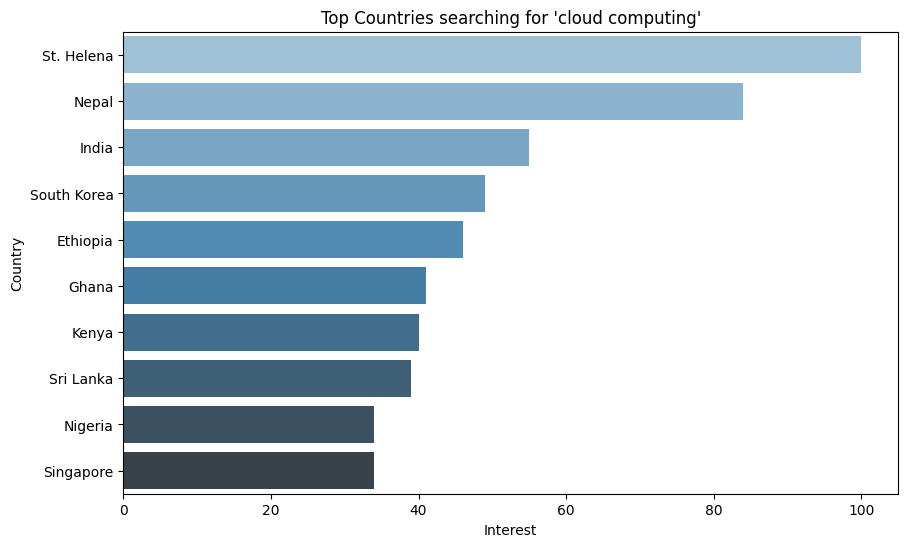

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(x=region_data[keyword], y=region_data.index, palette="Blues_d")

plt.title(f"Top Countries searching for '{keyword}'")

plt.xlabel("Interest")
plt.ylabel("Country")

plt.show()

In [38]:
!python -m pip install --upgrade pip


In [39]:
import pycountry


In [52]:
import plotly.express as px

# Reset the index so country names become a column
region_data = region_data.reset_index()

# Create the choropleth map
fig = px.choropleth(
    region_data,
    locations='geoName',                # column with country names
    locationmode='country names',       # tells Plotly these are full country names
    color=keyword,                      # column with search interest values
    title=f"Search Interest for '{keyword}' by Country",  # dynamic title
    color_continuous_scale='Blues'      # color gradient from light to dark blue
)

# Show the interactive map
fig.show()


C:\Users\SARS\AppData\Local\Temp\ipykernel_1128\927003494.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


# Time wise interest

In [54]:
time_df = pytrends.interest_over_time()


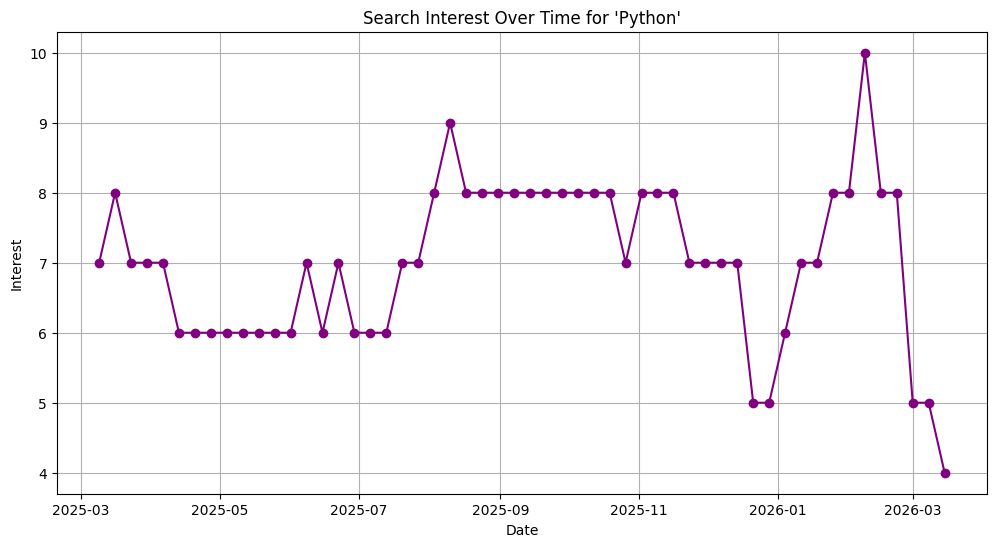

In [58]:
# Ignore 'isPartial' and pick the first column as your keyword
keyword_col = [col for col in time_df.columns if col != 'isPartial'][0]

plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword_col], marker='o', color='purple')
plt.title(f"Search Interest Over Time for '{keyword_col}'")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

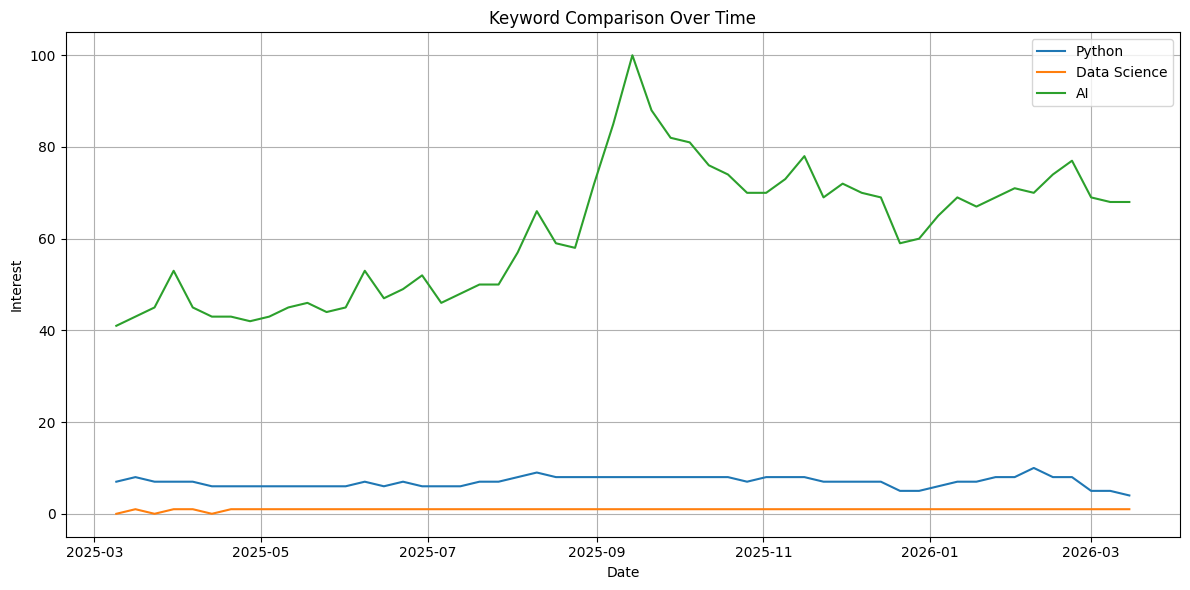

In [60]:
# Define the list of keywords you want to compare
kw_list = ['Python', 'Data Science', 'AI']  # example keywords

# Build payload for Pytrends
pytrends.build_payload(kw_list, timeframe='today 12-m', geo='', gprop='')

# Get interest over time
compare_df = pytrends.interest_over_time()

# Plot comparison
plt.figure(figsize=(12,6))

for kw in kw_list:
    plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("Keyword Comparison Over Time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion

#### This project analyzed Google search trends using Pytrends. It identified the top countries searching for the keyword and visualized worldwide interest with a choropleth map. The project tracked keyword trends over time and compared related keywords to see relative popularity. The workflow is dynamic, allowing quick updates by changing the keyword, making it useful for trend monitoring, marketing, and research insights.